In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


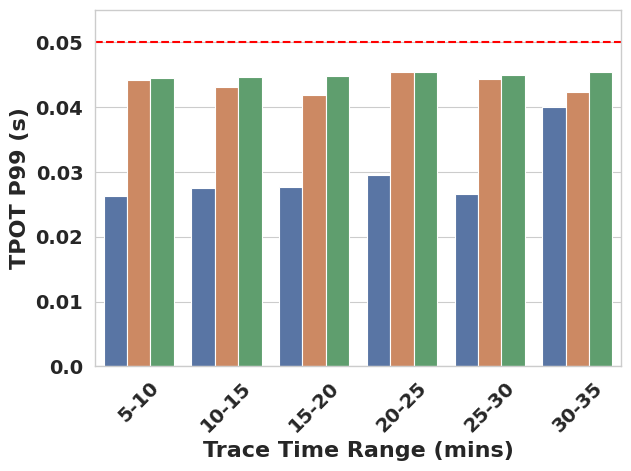

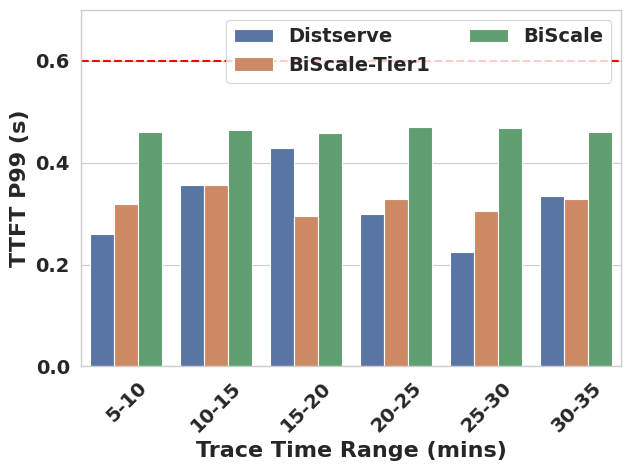

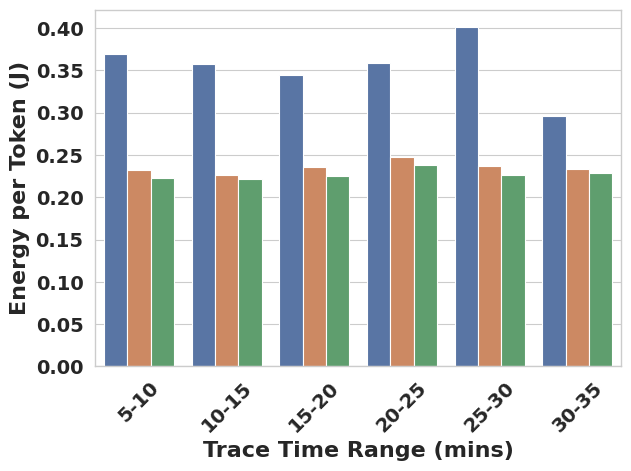

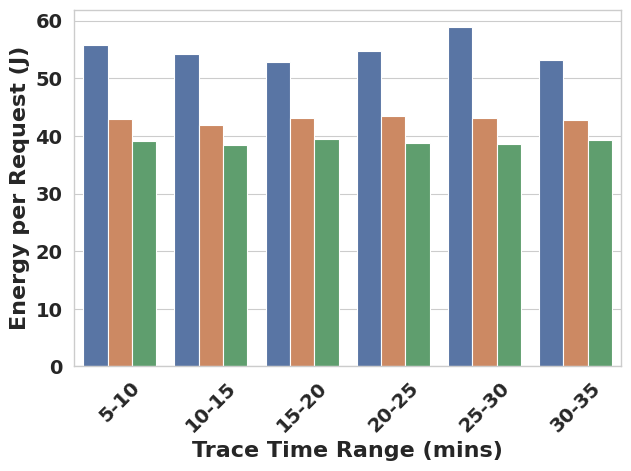

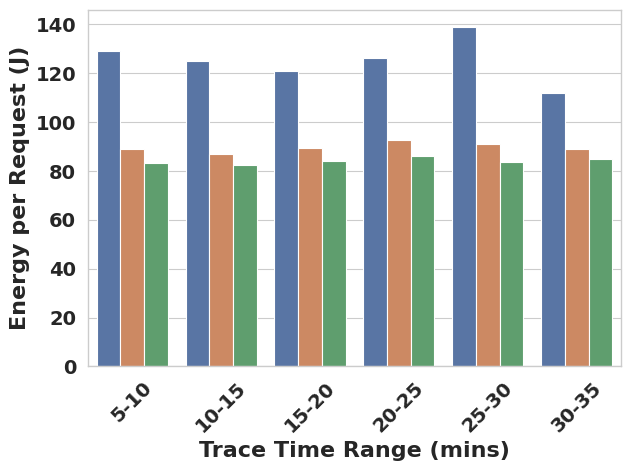

In [5]:
path_disag = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_0_Aug22_4nodes/disag/metrics.csv"
df_results_disag = pd.read_csv(path_disag)

path_coll = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_0_Aug22_4nodes/chunked/metrics.csv"
df_results_coll = pd.read_csv(path_coll)

df_results = pd.concat([df_results_disag, df_results_coll], ignore_index=True)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_6': 'Distserve 6',
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_5': 'Distserve 5',
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_4': 'Distserve 4',
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_3': 'Distserve 3',
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_2': 'Distserve 2',
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_1': 'Distserve 1',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_6': 'BiScale-Tier1 6',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_5': 'BiScale-Tier1 5',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_4': 'BiScale-Tier1 4',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_3': 'BiScale-Tier1 3',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_2': 'BiScale-Tier1 2',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_1': 'BiScale-Tier1 1',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_6_DVFS': 'BiScale 6',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_5_DVFS': 'BiScale 5',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_4_DVFS': 'BiScale 4',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_3_DVFS': 'BiScale 3',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_2_DVFS': 'BiScale 2',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_ORCALE_1_DVFS': 'BiScale 1',

}

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

df_results = df_results[df_results["expr_dir"].isin(set(rename_mapping.values()))].copy()

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
# df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale', 'Collocated-Tier1', 'Collocated'], ordered=True)
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

#################### TPOT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TPOT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.055)
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.01, 0.02, 0.03, 0.04, 0.05])
ax.set_yticklabels(['0.0', '0.01', '0.02', '0.03', '0.04', '0.05'], fontsize=14, fontweight='bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_tpot.pdf", format="pdf")

#################### TTFT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TTFT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.7)
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14, fontweight='bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
plt.tight_layout()
plt.savefig("figs/p67_oracle_ttft.pdf", format="pdf")

#################### Energy per token - decode ####################
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Token (J)', fontsize=16, fontweight='bold')
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_energy_per_token_decode.pdf", format="pdf")

#################### Energy per token - prefill ####################
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="prefill_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_energy_per_request_prefill.pdf", format="pdf")

#################### Energy per token - total ####################
df_results['energy_per_req'] = df_results['energy_j'] / df_results['num_requests']
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_req", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_energy_per_request_total.pdf", format="pdf")

In [ ]:
df_results = df_results[df_results["name"].isin(["Distserve", "BiScale-Tier1", "BiScale"])].copy()

# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_prefi_D'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_D'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_prefi_M'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_M'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_req'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_req'].values[0]) * 100,
    axis=1
)
df_results['energy_share_prefill'] = df_results['energy_prefill'] / (df_results['energy_j']) * 100
df_results['energy_share_decode'] = df_results['energy_decode'] / (df_results['energy_j']) * 100

summary_rows = []
for name in ["Distserve", "BiScale-Tier1", "BiScale"]:
    grp = df_results[df_results["name"] == name]
    row = grp.mean(numeric_only=True).to_dict()
    row["expr_dir"] = f"{name} avg"
    row["instance"] = "total"
    row["name"] = name
    row["rps"] = "avg"
    summary_rows.append(row)
df_results = pd.concat([df_results, pd.DataFrame(summary_rows)], ignore_index=True)

df_results[['expr_dir', 'energy_j', 'energy_prefill', 'energy_decode', 'energy_per_token', 'energy_per_req', 'energy_share_prefill', 'energy_share_decode', 'energy_norm_prefi_D', 'energy_norm_deco_D', 'energy_norm_prefi_M', 'energy_norm_deco_M', 'energy_norm_D']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_j,energy_prefill,energy_decode,energy_per_token,energy_per_req,energy_share_prefill,energy_share_decode,energy_norm_prefi_D,energy_norm_deco_D,energy_norm_prefi_M,energy_norm_deco_M,energy_norm_D
18,Distserve avg,3.256786e+06,1.425528e+06,1.831258e+06,0.628075,125.311160,43.927451,56.072549,0.000000,0.000000,-27.976286,-50.578902,0.000000
15,Distserve 6,2.514084e+06,1.194509e+06,1.319575e+06,0.561963,111.921114,47.512708,52.487292,0.000000,0.000000,-24.164493,-26.895543,0.000000
12,Distserve 5,3.281553e+06,1.392476e+06,1.889076e+06,0.694006,138.931117,42.433460,57.566540,0.000000,0.000000,-36.546808,-69.093102,0.000000
9,Distserve 4,3.425089e+06,1.487107e+06,1.937982e+06,0.630459,126.256593,43.418065,56.581935,0.000000,0.000000,-26.063562,-44.950540,0.000000
6,Distserve 3,3.479098e+06,1.519688e+06,1.959410e+06,0.608252,120.802012,43.680509,56.319491,0.000000,0.000000,-22.412444,-45.881541,0.000000
3,Distserve 2,3.445781e+06,1.491996e+06,1.953785e+06,0.626541,125.055553,43.299214,56.700786,0.000000,0.000000,-29.055270,-57.795745,0.000000
0,Distserve 1,3.395112e+06,1.467393e+06,1.927719e+06,0.647226,128.900571,43.220752,56.779248,0.000000,0.000000,-29.615138,-58.856940,0.000000
19,BiScale-Tier1 avg,2.328974e+06,1.115358e+06,1.213616e+06,0.449711,89.632988,47.896458,52.103542,21.762158,33.032567,0.000000,0.000000,28.191400
16,BiScale-Tier1 6,2.001641e+06,9.621235e+05,1.039517e+06,0.447578,89.100415,48.066739,51.933261,19.461677,21.195026,0.000000,0.000000,20.389986
13,BiScale-Tier1 5,2.146104e+06,1.020298e+06,1.125807e+06,0.450412,90.813486,47.541849,52.458151,26.765040,40.860982,0.000000,0.000000,34.634164
